# EDA - FIFA World Cup 2026 (Player & Team Performance)

**Objetivo:** explorar y validar el dataset de rendimiento de jugadores y equipos del Mundial 2026, generar insights de scouting/performance, y dejar los datos modelados en un esquema estrella (Dim/Fact) listos para cargarse en Power BI.

**Fuente de datos:** `fifa_world_cup_2026_player_performance.csv` (una fila por jugador y partido).

In [3]:
# Librerías principales para análisis y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga de los datos

In [4]:
# Carga del dataset
file_path = (r"...Data\fifa_world_cup_2026_player_performance.csv")

df = pd.read_csv(file_path)
print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [5]:
df.head(3)

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

## 2. Calidad de datos

In [7]:
total_nulls = df.isnull().sum().sum()
print(f"Valores nulos totales: {total_nulls}")

Valores nulos totales: 0


In [8]:
duplicated_rows = df.duplicated().sum()
print(f"Filas completamente duplicadas: {duplicated_rows:,}")

Filas completamente duplicadas: 0


**Decisión:** *El dataset no tiene valores nulos* 

In [9]:
df["match_date"] = pd.to_datetime(df["match_date"])

print(f"Fecha mínima: {df['match_date'].min().date()}")
print(f"Fecha máxima: {df['match_date'].max().date()}")

Fecha mínima: 2026-06-11
Fecha máxima: 2026-07-31


In [10]:
age_validation = df["age"].between(18, 45)

print(f"Registros con edad fuera del rango esperado: {(~age_validation).sum():,}")

Registros con edad fuera del rango esperado: 239


## 3. Distribuciones categóricas

In [11]:
print("Posiciones:")
print(df["position"].value_counts())

print("\nPie dominante:")
print(df["preferred_foot"].value_counts())

print("\nResultado del partido:")
print(df["match_result"].value_counts())

print("\nFases del torneo:")
print(df["tournament_stage"].value_counts())

Posiciones:
position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64

Pie dominante:
preferred_foot
Right    40656
Left     13944
Name: count, dtype: int64

Resultado del partido:
match_result
W    20124
L    20124
D    14352
Name: count, dtype: int64

Fases del torneo:
tournament_stage
Group Stage          30056
Round of 32           9256
Round of 16           6552
Quarter Finals        4368
Semi Finals           2184
Third Place Match     1092
Final                 1092
Name: count, dtype: int64


In [12]:
records_per_match = df.groupby("match_id").size()

records_per_match.describe()

count    1050.0
mean       52.0
std         0.0
min        52.0
25%        52.0
50%        52.0
75%        52.0
max        52.0
dtype: float64

## 4. Estadísticas descriptivas

In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
age,54600.0,26.296484,17.0,23.0,26.0,29.0,39.0,4.067519
jersey_number,54600.0,13.5,1.0,7.0,13.5,20.0,26.0,7.500069
height_cm,54600.0,181.654341,163.0,177.0,182.0,186.0,200.0,6.277792
weight_kg,54600.0,75.754853,65.0,73.0,76.0,78.0,87.0,3.951481
market_value_eur,54600.0,20084451.764725,528822.0,4444778.0,10271107.0,23420128.0,200000000.0,27188660.404574
...,...,...,...,...,...,...,...,...
total_goals_tournament,54600.0,0.643993,0.0,0.0,0.0,1.0,10.0,1.093781
total_assists_tournament,54600.0,0.607601,0.0,0.0,0.0,1.0,8.0,0.931527
total_minutes_tournament,54600.0,272.300311,0.0,184.0,268.0,359.0,615.0,116.806184
player_of_match_awards,54600.0,0.030659,0.0,0.0,0.0,0.0,4.0,0.20652


In [14]:
descriptive_stats = df.describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
]

descriptive_stats

,count,mean,std,min,50%,max
age,54600.0,26.296484,4.067519,17.0,26.0,39.0
jersey_number,54600.0,13.5,7.500069,1.0,13.5,26.0
height_cm,54600.0,181.654341,6.277792,163.0,182.0,200.0
weight_kg,54600.0,75.754853,3.951481,65.0,76.0,87.0
market_value_eur,54600.0,20084451.764725,27188660.404574,528822.0,10271107.0,200000000.0
...,...,...,...,...,...,...
total_goals_tournament,54600.0,0.643993,1.093781,0.0,0.0,10.0
total_assists_tournament,54600.0,0.607601,0.931527,0.0,0.0,8.0
total_minutes_tournament,54600.0,272.300311,116.806184,0.0,268.0,615.0
player_of_match_awards,54600.0,0.030659,0.20652,0.0,0.0,4.0


## 5. Análisis de jugadores (posición, edad, pie dominante)

In [15]:
position_counts = (
    df[["player_id", "position"]]
    .drop_duplicates("player_id")
    ["position"]
    .value_counts()
)

position_counts

position
Defender      432
Midfielder    384
Forward       288
Goalkeeper    144
Name: count, dtype: int64

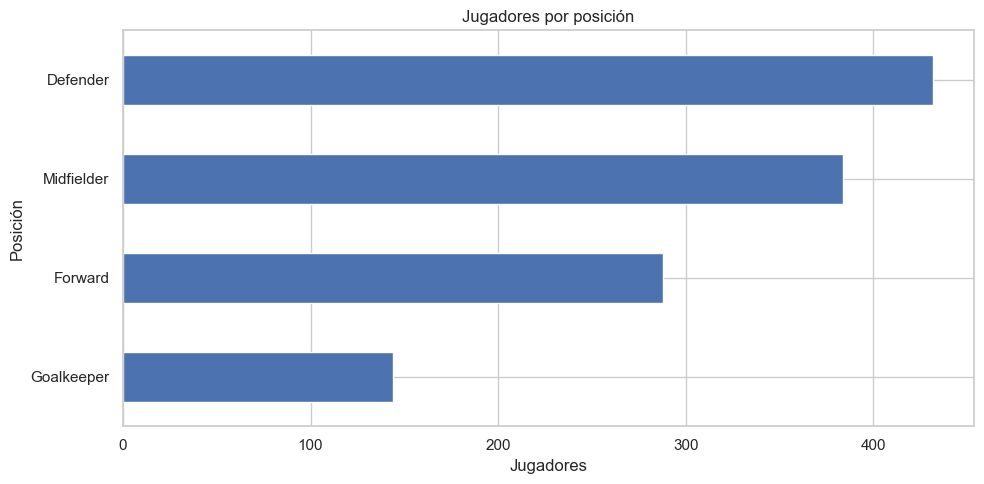

In [16]:
plt.figure(figsize=(10, 5))

position_counts.sort_values().plot(
    kind="barh",
    title="Jugadores por posición"
)

plt.xlabel("Jugadores")
plt.ylabel("Posición")
plt.tight_layout()
plt.show()

**Insight:** — La posición con mas jugadores convocados es la defensiva, tomando en cuenta la calidad de los delanteros.

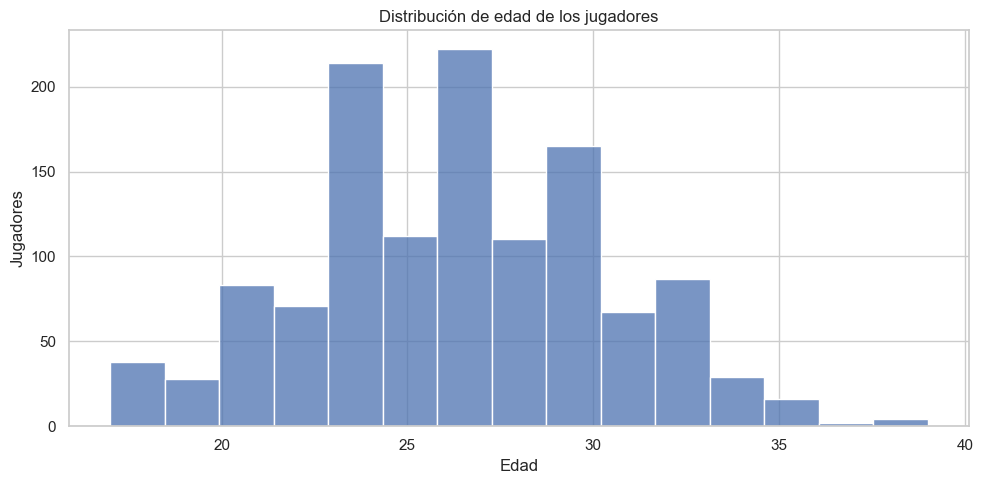

In [17]:
players = df.drop_duplicates("player_id")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=players,
    x="age",
    bins=15
)

plt.title("Distribución de edad de los jugadores")
plt.xlabel("Edad")
plt.ylabel("Jugadores")
plt.tight_layout()
plt.show()

**Insight:** — Los diferentes equipos/naciones tiene una concentración de jugadores entre los 23 y 27 años.

In [18]:
foot_distribution = (
    players["preferred_foot"]
    .value_counts()
)

foot_distribution

preferred_foot
Right    928
Left     320
Name: count, dtype: int64

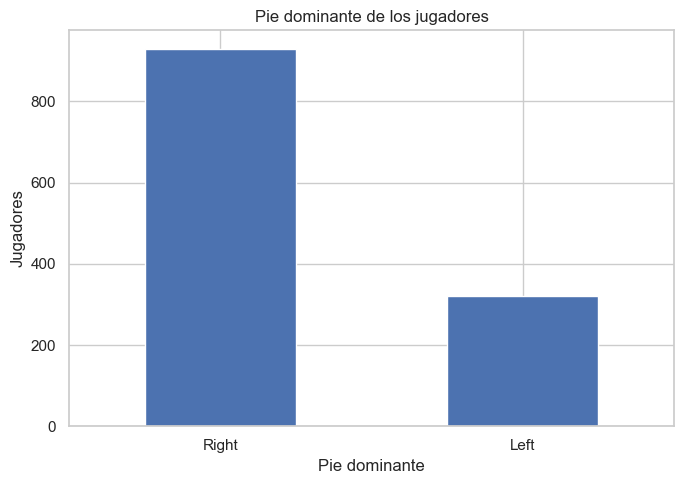

In [19]:
plt.figure(figsize=(7, 5))

foot_distribution.plot(
    kind="bar",
    title="Pie dominante de los jugadores"
)

plt.xlabel("Pie dominante")
plt.ylabel("Jugadores")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Valor de mercado

In [20]:
market_value = (
    players[
        ["player_name", "position", "market_value_eur"]
    ]
    .sort_values(
        "market_value_eur",
        ascending=False
    )
)

market_value.head(15)

,player_name,position,market_value_eur
174,Houssem Mokrani,Midfielder,200000000
1495,Romelu Onana,Midfielder,200000000
1295,Saleh Al-Qahtani,Forward,200000000
846,Dominik Kramaric,Forward,190657094
2740,Jesus Reyes,Midfielder,170783688
84,Memphis Zerrouki,Forward,154445945
331,Rasmus Andersen,Defender,148079777
1284,Ali Al-Buraikan,Midfielder,147161557
56,Gianluca Peña,Midfielder,146864940
1744,Burak Soyuncu,Forward,142059273


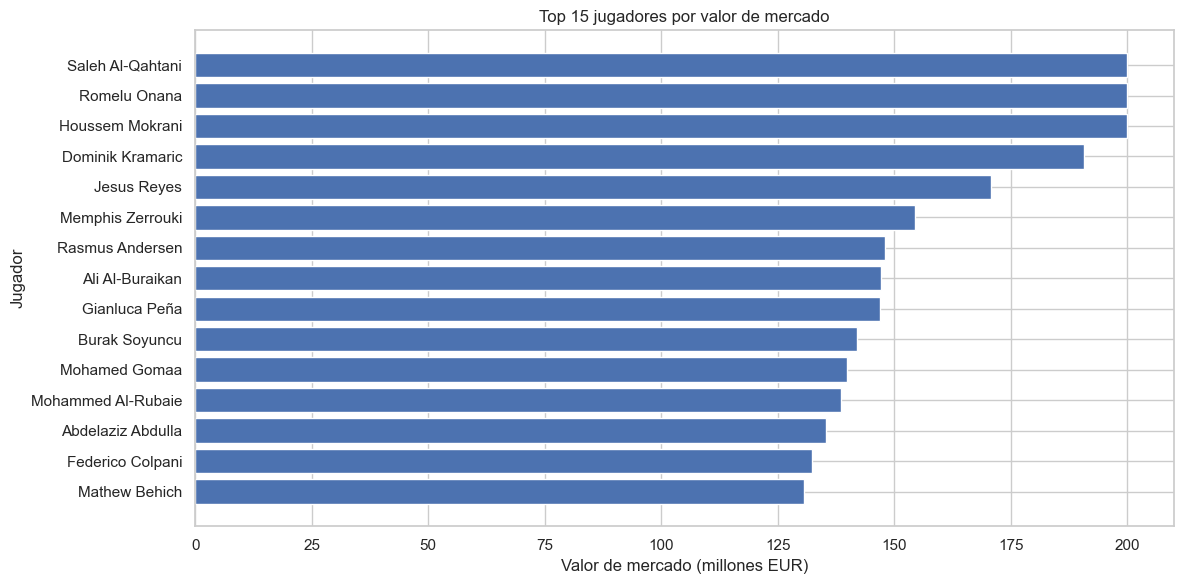

In [21]:
plt.figure(figsize=(12, 6))

top_market = market_value.head(15).sort_values(
    "market_value_eur"
)

plt.barh(
    top_market["player_name"],
    top_market["market_value_eur"] / 1_000_000
)

plt.title("Top 15 jugadores por valor de mercado")
plt.xlabel("Valor de mercado (millones EUR)")
plt.ylabel("Jugador")
plt.tight_layout()
plt.show()

## 7. Rendimiento ofensivo

In [31]:
offensive_summary = (
    df.groupby("player_name")
      .agg(
          Goals=("goals", "sum"),
          Assists=("assists", "sum"),
          Shots=("shots", "sum"),
          Shots_on_Target=("shots_on_target", "sum"),
          xG=("expected_goals_xg", "sum"),
          xA=("expected_assists_xa", "sum")
      )
      .sort_values("Goals", ascending=False)
)

offensive_summary.head(15)

,Goals,Assists,Shots,Shots_on_Target,xG,xA
player_name,,,,,,
Memphis Zerrouki,24,9,82,17,3.22,1.60
Kasey Hector,16,9,77,15,2.90,1.39
Vinicius Nunes,15,6,88,23,4.99,0.66
Dominik Kramaric,15,9,79,15,5.72,1.19
Mohannad Majeed,15,10,53,9,2.13,1.66
Eric Rodriguez,15,5,71,10,2.15,2.06
Randal Duarte,14,6,49,8,2.77,0.91
Eric Mba,14,7,105,26,3.15,3.35
Abdelaziz Abdulla,13,6,86,15,5.96,4.36


In [32]:
top_scorers = (
    df.groupby("player_name")["goals"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

top_scorers

player_name
Memphis Zerrouki       24
Kasey Hector           16
Vinicius Nunes         15
Dominik Kramaric       15
Mohannad Majeed        15
Eric Rodriguez         15
Randal Duarte          14
Eric Mba               14
Abdelaziz Abdulla      13
Andre Bassogog         13
Gianluigi Calafiori    13
Paolo Gonzalez         13
Saleh Al-Qahtani       13
Saman Azmoun           13
Themba Xoki            13
Name: goals, dtype: int64

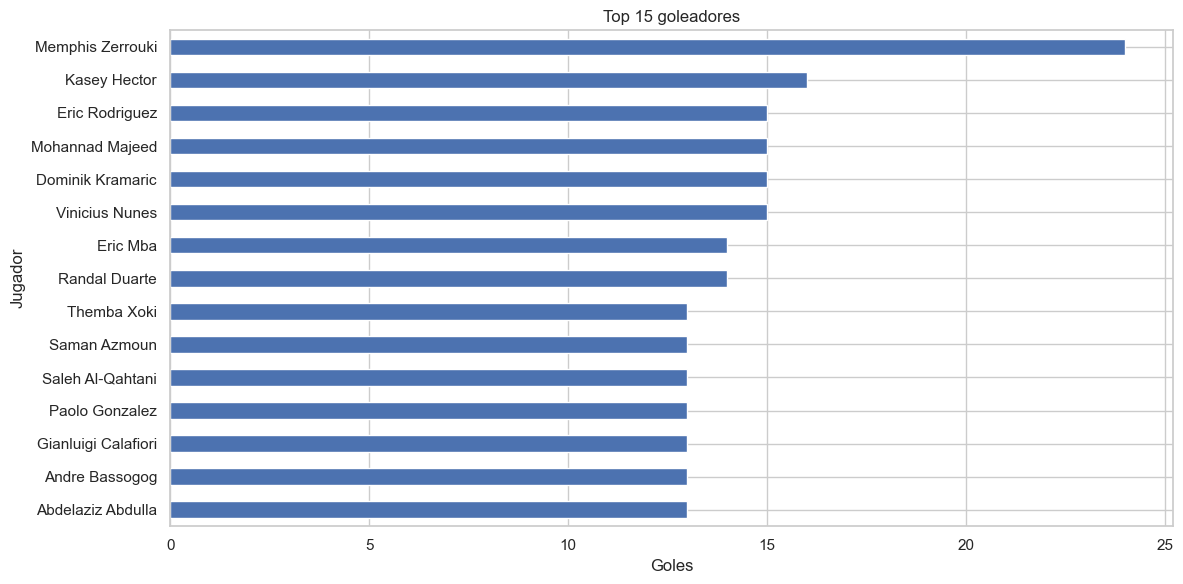

In [33]:
plt.figure(figsize=(12, 6))

top_scorers.sort_values().plot(
    kind="barh",
    title="Top 15 goleadores"
)

plt.xlabel("Goles")
plt.ylabel("Jugador")
plt.tight_layout()
plt.show()

## 8. Creación de juego

In [34]:
creation_summary = (
    df.groupby("player_name")
      .agg(
          Key_Passes=("key_passes", "sum"),
          Successful_Passes=("successful_passes", "sum"),
          Total_Passes=("total_passes", "sum"),
          Assists=("assists", "sum"),
          xA=("expected_assists_xa", "sum"),
          Dribbles=("successful_dribbles", "sum")
      )
      .sort_values(
          "Key_Passes",
          ascending=False
      )
)

creation_summary.head(15)

,Key_Passes,Successful_Passes,Total_Passes,Assists,xA,Dribbles
player_name,,,,,,
Frenkie Ake,87,2078,2523,6,4.89,22
Romain Aboukhlal,83,2068,2496,3,1.51,30
Gavi Ramos,80,1688,2026,7,3.63,24
Sofyan Chair,80,1741,2089,6,2.09,22
Eldor Miralimov,77,1801,2132,4,4.72,16
Mohammed Otoo,76,1896,2240,7,3.13,23
John Armstrong,76,1847,2142,10,4.97,21
Yassine El Yamiq,75,1737,2051,13,3.02,24
Ali Al-Buraikan,75,2049,2440,4,3.40,22


## 9. Rendimiento defensivo

In [35]:
defensive_summary = (
    df.groupby("player_name")
      .agg(
          Tackles=("tackles", "sum"),
          Interceptions=("interceptions", "sum"),
          Clearances=("clearances", "sum"),
          Blocks=("blocks", "sum"),
          Defensive_Actions=("defensive_actions", "sum"),
          Recoveries=("recoveries", "sum"),
          Aerial_Duels_Won=("aerial_duels_won", "sum")
      )
      .sort_values(
          "Defensive_Actions",
          ascending=False
      )
)

defensive_summary.head(15)

,Tackles,Interceptions,Clearances,Blocks,Defensive_Actions,Recoveries,Aerial_Duels_Won
player_name,,,,,,,
Abdulrahman Al-Hamdan,103,99,152,39,393,120,96
Akram Hatem,85,83,145,31,344,119,72
Leon Lowe,99,81,132,24,336,178,77
Karim Barsham,105,74,116,31,326,76,61
Ante Budimir,84,87,119,33,323,208,70
Achraf Bounou,107,81,109,25,322,117,83
André Yotun,94,73,131,22,320,135,58
Ahmed Al-Dosari,105,69,110,24,308,174,61
Cody Dumfries,87,66,123,30,306,147,65


## 10. Análisis de porteros

In [22]:
goalkeepers = df[df["position"] == "Goalkeeper"].copy()

print(
    f"Registros correspondientes a porteros: "
    f"{len(goalkeepers):,}"
)

Registros correspondientes a porteros: 6,300


In [23]:
goalkeeper_summary = (
    goalkeepers.groupby("player_name")
    .agg(
        Saves=("saves", "sum"),
        Goals_Conceded=("goals_conceded", "sum"),
        Clean_Sheets=("clean_sheet", "sum"),
        Penalty_Saves=("penalty_saves", "sum"),
        Matches=("match_id", "nunique")
    )
    .sort_values(
        "Saves",
        ascending=False
    )
)

goalkeeper_summary.head(15)

,Saves,Goals_Conceded,Clean_Sheets,Penalty_Saves,Matches
player_name,,,,,
Nicolo Immobile,87,37,2,3,53
Michail Gray,84,31,3,2,59
Hassan Abdulla,79,30,4,0,66
Joel Borges,78,36,4,0,46
Harry Bellingham,77,29,2,0,44
Kalidou Mendy,76,25,1,2,38
Federico Bentancur,76,25,6,1,45
Cengiz Soyuncu,72,24,6,1,50
Leon Antonio,69,29,7,3,59


## 11. Scouting multidimensional

In [38]:
scouting_summary = (
    df.groupby("player_name")
      .agg(
          Performance=("performance_score", "mean"),
          Offensive_Contribution=("offensive_contribution", "mean"),
          Defensive_Contribution=("defensive_contribution", "mean"),
          Possession_Impact=("possession_impact", "mean"),
          Pressure_Resistance=("pressure_resistance", "mean"),
          Creativity=("creativity_score", "mean"),
          Consistency=("consistency_score", "mean"),
          Clutch=("clutch_performance_score", "mean")
      )
)

scouting_summary.sort_values(
    "Performance",
    ascending=False
).head(15)

,Performance,Offensive_Contribution,Defensive_Contribution,Possession_Impact,Pressure_Resistance,Creativity,Consistency,Clutch
player_name,,,,,,,,
Pepe Carvalho,57.602326,55.430233,98.132558,10.355814,89.660465,29.223256,97.846512,63.588372
Declan Trippier,55.738636,44.936364,93.438636,6.679545,80.590909,33.993182,87.163636,61.627273
Giovanni Tillman,55.410526,76.976316,72.610526,10.136842,79.944737,79.521053,88.568421,61.555263
Daichi Hashioka,55.363889,88.205556,26.097222,5.975000,81.236111,75.511111,89.791667,60.536111
Eric Mba,54.377273,96.504545,25.468182,7.770455,93.952273,91.086364,95.838636,60.234091
Stefan Lainer,54.275758,93.784848,23.484848,6.112121,80.821212,84.606061,89.130303,59.227273
Ali Al-Buraikan,54.132692,80.113462,71.453846,9.369231,87.248077,82.792308,87.661538,59.919231
Raul Torres,53.882500,96.482500,23.725000,7.845000,96.115000,93.160000,96.440000,58.397500
Rasmus Laursen,53.746512,76.309302,73.316279,7.906977,85.644186,82.574419,89.865116,58.909302


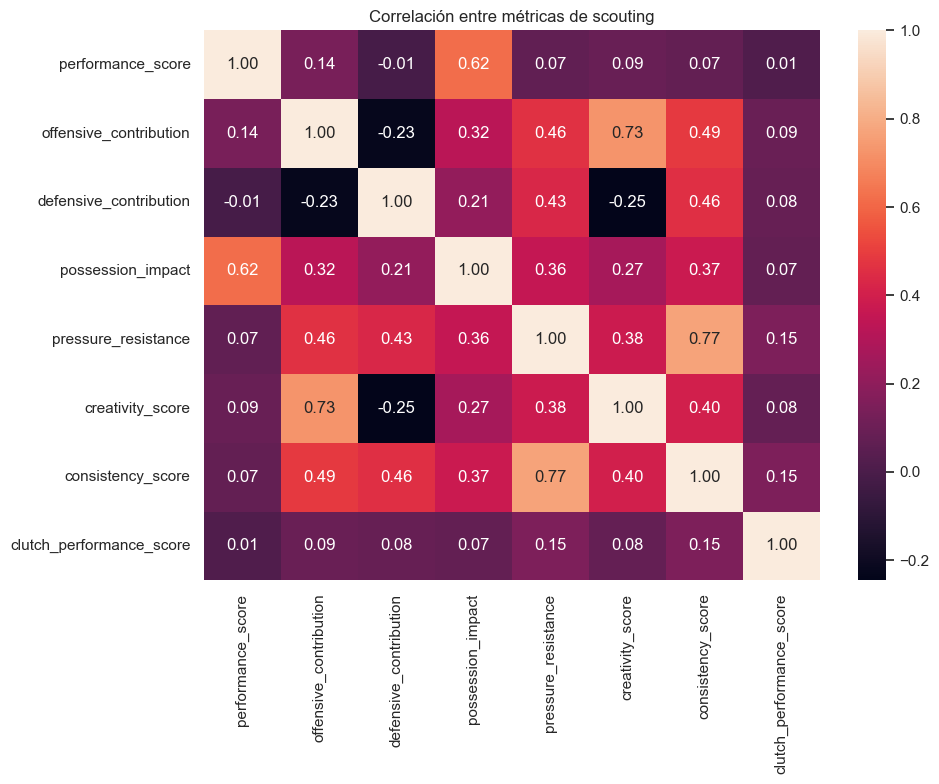

In [39]:
scouting_dimensions = [
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "possession_impact",
    "pressure_resistance",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score"
]

scouting_correlations = df[scouting_dimensions].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    scouting_correlations,
    annot=True,
    fmt=".2f"
)

plt.title("Correlación entre métricas de scouting")
plt.tight_layout()
plt.show()

## 12. Análisis a nivel de selección

In [41]:
team_match = (
    df[
        [
            "match_id",
            "team",
            "opponent_team",
            "goals_team",
            "goals_opponent",
            "match_result"
        ]
    ]
    .drop_duplicates(
        subset=["match_id", "team"]
    )
)

team_match.head(15)

,match_id,team,opponent_team,goals_team,goals_opponent,match_result
0,M00001,Spain,South Africa,1,0,W
26,M00001,South Africa,Spain,0,1,L
52,M00002,Peru,Netherlands,2,1,W
78,M00002,Netherlands,Peru,1,2,L
104,M00003,Morocco,Senegal,0,1,L
130,M00003,Senegal,Morocco,1,0,W
156,M00004,Algeria,Italy,2,0,W
182,M00004,Italy,Algeria,0,2,L
208,M00005,Brazil,Netherlands,0,0,D
234,M00005,Netherlands,Brazil,0,0,D


In [43]:
team_results = (
    team_match.groupby("team")
    .agg(
        Matches=("match_id", "nunique"),
        Goals_Scored=("goals_team", "sum"),
        Goals_Conceded=("goals_opponent", "sum")
    )
)

team_results["Goal_Difference"] = (
    team_results["Goals_Scored"] -
    team_results["Goals_Conceded"]
)

team_results.sort_values(
    "Goals_Scored",
    ascending=False
).head(15)

,Matches,Goals_Scored,Goals_Conceded,Goal_Difference
team,,,,
Qatar,66,103,94,9
Jamaica,59,88,80,8
Belgium,51,79,70,9
Morocco,55,78,54,24
Brazil,45,73,53,20
Italy,53,72,77,-5
Scotland,49,72,57,15
Saudi Arabia,52,71,70,1
Turkey,50,70,69,1


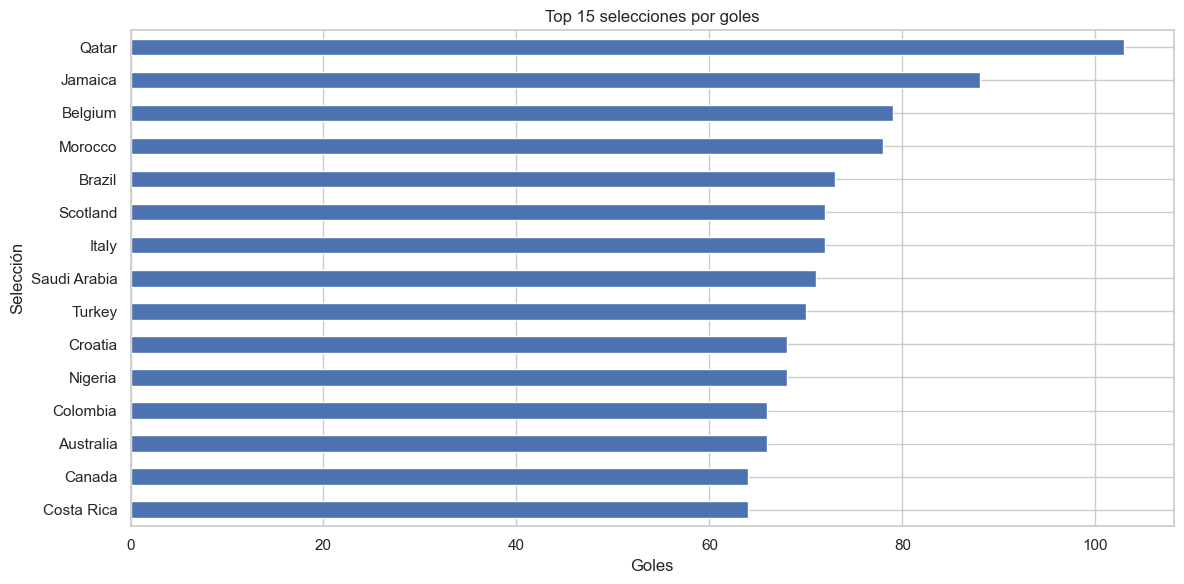

In [44]:
top_teams_goals = (
    team_results["Goals_Scored"]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

top_teams_goals.sort_values().plot(
    kind="barh",
    title="Top 15 selecciones por goles"
)

plt.xlabel("Goles")
plt.ylabel("Selección")
plt.tight_layout()
plt.show()

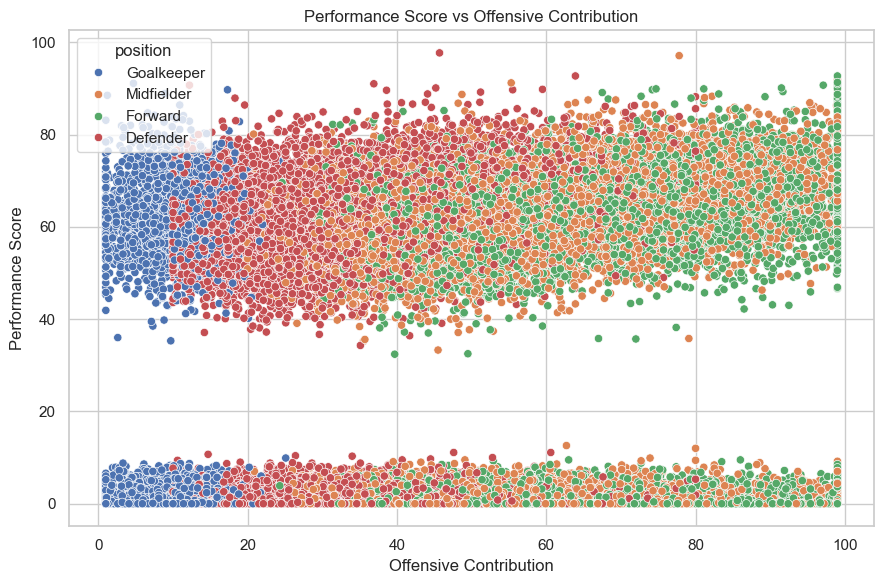

In [45]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="offensive_contribution",
    y="performance_score",
    hue="position"
)

plt.title(
    "Performance Score vs Offensive Contribution"
)

plt.xlabel("Offensive Contribution")
plt.ylabel("Performance Score")
plt.tight_layout()
plt.show()

## 13. Resumen general del dataset

In [29]:
summary = pd.Series({
    "Registros": len(df),
    "Jugadores": df["player_id"].nunique(),
    "Partidos": df["match_id"].nunique(),
    "Selecciones": df["team"].nunique(),
    "Posiciones": df["position"].nunique(),
    "Fecha inicial": df["match_date"].min().date(),
    "Fecha final": df["match_date"].max().date(),
    "Nulos": int(df.isnull().sum().sum()),
    "Duplicados completos": int(df.duplicated().sum())
})

summary

Registros                    54600
Jugadores                     1248
Partidos                      1050
Selecciones                     48
Posiciones                       4
Fecha inicial           2026-06-11
Fecha final             2026-07-31
Nulos                            0
Duplicados completos             0
dtype: object

## 14. Modelado en esquema estrella para Power BI

Se separan las dimensiones (`Dim_Player`, `Dim_Team`, `Dim_Match`, `Dim_Date`) y las tablas de hechos (`Fact_Player_Match`, `Fact_Team_Match`).

In [30]:
cols_player = [
    "player_id",
    "player_name",
    "age",
    "nationality",
    "position",
    "height_cm",
    "weight_kg",
    "preferred_foot",
    "club_name",
    "market_value_eur"
]

dim_player = (
    df[cols_player]
    .drop_duplicates("player_id")
    .copy()
)

dim_player.head()

,player_id,player_name,age,nationality,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur
0,P00055,Rodri Fati,26,Spanish,Goalkeeper,195,75,Left,RB Salzburg,4384884
1,P00070,Ansu Le Normand,19,Spanish,Midfielder,178,75,Right,Chelsea,4918927
2,P00066,Gavi Ramos,18,Spanish,Midfielder,177,72,Left,AIK,125015698
3,P00073,Pedro Cubarsi,20,Spanish,Forward,182,74,Right,PSV Eindhoven,11805512
4,P00059,Alvaro Oyarzabal,23,Spanish,Defender,191,81,Left,Juventus,13325174


In [31]:
teams = pd.concat([
    df[["team"]].rename(columns={"team": "team_name"}),
    df[["opponent_team"]].rename(columns={"opponent_team": "team_name"})
])

dim_team = (
    teams
    .drop_duplicates()
    .sort_values("team_name")
    .reset_index(drop=True)
)

dim_team["team_id"] = range(1, len(dim_team) + 1)

dim_team = dim_team[
    ["team_id", "team_name"]
]

dim_team.head()

,team_id,team_name
0,1,Algeria
1,2,Argentina
2,3,Australia
3,4,Austria
4,5,Belgium


In [32]:
cols_match = [
    "match_id",
    "match_date",
    "stadium",
    "city",
    "tournament_stage"
]

dim_match = (
    df[cols_match]
    .drop_duplicates("match_id")
    .copy()
)

dim_match.head()

,match_id,match_date,stadium,city,tournament_stage
0,M00001,2026-07-10,Hard Rock Stadium,Miami,Group Stage
52,M00002,2026-07-16,Arrowhead Stadium,Kansas City,Group Stage
104,M00003,2026-07-04,Gillette Stadium,Boston,Group Stage
156,M00004,2026-06-13,Lincoln Financial Field,Philadelphia,Group Stage
208,M00005,2026-06-25,Hard Rock Stadium,Miami,Group Stage


In [33]:
dim_date = pd.DataFrame({
    "Date": pd.date_range(
        start=df["match_date"].min(),
        end=df["match_date"].max(),
        freq="D"
    )
})

dim_date["Year"] = dim_date["Date"].dt.year
dim_date["Month_Number"] = dim_date["Date"].dt.month
dim_date["Month"] = dim_date["Date"].dt.month_name()
dim_date["Quarter"] = "Q" + dim_date["Date"].dt.quarter.astype(str)
dim_date["Year_Month"] = (
    dim_date["Date"].dt.to_period("M").astype(str)
)
dim_date["Day"] = dim_date["Date"].dt.day
dim_date["Day_of_Week_Number"] = (
    dim_date["Date"].dt.dayofweek + 1
)
dim_date["Day_of_Week"] = (
    dim_date["Date"].dt.day_name()
)

dim_date.head()

,Date,Year,Month_Number,Month,Quarter,Year_Month,Day,Day_of_Week_Number,Day_of_Week
0,2026-06-11,2026,6,June,Q2,2026-06,11,4,Thursday
1,2026-06-12,2026,6,June,Q2,2026-06,12,5,Friday
2,2026-06-13,2026,6,June,Q2,2026-06,13,6,Saturday
3,2026-06-14,2026,6,June,Q2,2026-06,14,7,Sunday
4,2026-06-15,2026,6,June,Q2,2026-06,15,1,Monday


In [35]:
player_fact_columns = [
    "player_id",
    "match_id",
    "team",
    "opponent_team",
    "minutes_played",
    "goals",
    "assists",
    "shots",
    "shots_on_target",
    "expected_goals_xg",
    "expected_assists_xa",
    "key_passes",
    "successful_passes",
    "total_passes",
    "pass_accuracy",
    "dribbles_attempted",
    "successful_dribbles",
    "crosses",
    "successful_crosses",
    "tackles",
    "interceptions",
    "clearances",
    "blocks",
    "aerial_duels_won",
    "aerial_duels_lost",
    "recoveries",
    "defensive_actions",
    "fouls_committed",
    "fouls_suffered",
    "yellow_cards",
    "red_cards",
    "offsides",
    "saves",
    "save_percentage",
    "punches",
    "clean_sheet",
    "goals_conceded",
    "penalty_saves",
    "distance_covered_km",
    "sprint_distance_km",
    "top_speed_kmh",
    "accelerations",
    "decelerations",
    "stamina_score",
    "player_rating",
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "possession_impact",
    "pressure_resistance",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score"
]

fact_player_match = df[player_fact_columns].copy()

# Reemplazamos nombre de equipo por team_id (llave foránea real hacia Dim_Team)
fact_player_match = fact_player_match.merge(
    dim_team.rename(columns={"team_id": "team_id", "team_name": "team"}),
    on="team", how="left"
).merge(
    dim_team.rename(columns={"team_id": "opponent_team_id", "team_name": "opponent_team"}),
    on="opponent_team", how="left"
).drop(columns=["team", "opponent_team"])

print(f"Filas de Fact_Player_Match: {len(fact_player_match):,}")
fact_player_match.head()

Filas de Fact_Player_Match: 54,600


,player_id,match_id,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,team_id,opponent_team_id
0,P00055,M00001,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,40,38
1,P00070,M00001,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,40,38
2,P00066,M00001,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,40,38
3,P00073,M00001,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,40,38
4,P00059,M00001,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,40,38


In [36]:
team_fact_columns = [
    "match_id",
    "team",
    "opponent_team",
    "goals_team",
    "goals_opponent",
    "match_result",
    "tournament_stage"
]

fact_team_match = (
    df[team_fact_columns]
    .drop_duplicates(
        subset=["match_id", "team"]
    )
    .copy()
)

fact_team_match = fact_team_match.merge(
    dim_team.rename(columns={"team_id": "team_id", "team_name": "team"}),
    on="team", how="left"
).merge(
    dim_team.rename(columns={"team_id": "opponent_team_id", "team_name": "opponent_team"}),
    on="opponent_team", how="left"
).drop(columns=["team", "opponent_team"])

fact_team_match.head()

,match_id,goals_team,goals_opponent,match_result,tournament_stage,team_id,opponent_team_id
0,M00001,1,0,W,Group Stage,40,38
1,M00001,0,1,L,Group Stage,38,40
2,M00002,2,1,W,Group Stage,30,27
3,M00002,1,2,L,Group Stage,27,30
4,M00003,0,1,L,Group Stage,26,36


In [38]:
print("Dimensiones")
print(f"Dim_Player: {len(dim_player):,} filas")
print(f"Dim_Team: {len(dim_team):,} filas")
print(f"Dim_Match: {len(dim_match):,} filas")
print(f"Dim_Date: {len(dim_date):,} filas")

print("\nHechos")
print(f"Fact_Player_Match: {len(fact_player_match):,} filas")
print(f"Fact_Team_Match: {len(fact_team_match):,} filas")

Dimensiones
Dim_Player: 1,248 filas
Dim_Team: 48 filas
Dim_Match: 1,050 filas
Dim_Date: 51 filas

Hechos
Fact_Player_Match: 54,600 filas
Fact_Team_Match: 2,100 filas


## 15. Exportación de tablas para Power BI

In [40]:
import os

output_path = r"...\Data"

os.makedirs(output_path, exist_ok=True)

In [41]:
dim_player.to_csv(
    f"{output_path}/Dim_Player.csv",
    index=False
)

dim_team.to_csv(
    f"{output_path}/Dim_Team.csv",
    index=False
)

dim_match.to_csv(
    f"{output_path}/Dim_Match.csv",
    index=False
)

dim_date.to_csv(
    f"{output_path}/Dim_Date.csv",
    index=False
)

fact_player_match.to_csv(
    f"{output_path}/Fact_Player_Match.csv",
    index=False
)

fact_team_match.to_csv(
    f"{output_path}/Fact_Team_Match.csv",
    index=False
)

print("Tablas preparadas para Power BI y exportadas correctamente.")

Tablas preparadas para Power BI y exportadas correctamente.
